In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv


# Loading dataset

In [2]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv"
)

print(df.shape)

df.head()

(6335, 4)


,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [3]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv"
)

print(df.shape)

df.head()

(6335, 4)


,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [4]:
df = df.drop_duplicates()

print("After removing duplicates:")
print(df.shape)

After removing duplicates:
(6335, 4)


In [5]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [6]:
print(
    "Duplicate texts:",
    df["text"].duplicated().sum()
)

Duplicate texts: 275


In [7]:
df = df.drop_duplicates(
    subset=["text"]
)

print(
    "After text duplicate removal:",
    df.shape
)

After text duplicate removal: (6060, 4)


In [8]:
print(
    "Final shape:",
    df.shape
)

Final shape: (6060, 4)


In [9]:
print(
    df["text"].duplicated().sum()
)

0


In [10]:
X = df["text"]

y = df["label"]

print("X shape:", X.shape)

print("y shape:", y.shape)

X shape: (6060,)
y shape: (6060,)


In [11]:
print(
    y.value_counts()
)

label
FAKE    3071
REAL    2989
Name: count, dtype: int64


# Dataset Splitting

In [12]:
from sklearn.model_selection import train_test_split

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train_text))
print("Temp:", len(X_temp_text))

Train: 4242
Temp: 1818


In [13]:
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Validation:", len(X_val_text))
print("Test:", len(X_test_text))

Validation: 909
Test: 909


In [14]:
print("Train labels:")
print(y_train.value_counts())

print("\nValidation labels:")
print(y_val.value_counts())

print("\nTest labels:")
print(y_test.value_counts())

Train labels:
label
FAKE    2150
REAL    2092
Name: count, dtype: int64

Validation labels:
label
FAKE    460
REAL    449
Name: count, dtype: int64

Test labels:
label
FAKE    461
REAL    448
Name: count, dtype: int64


## Data leakage check

In [15]:
print(
len(
set(X_train_text)
&
set(X_val_text)
)
)


0


In [16]:
print(
len(
set(X_train_text)
&
set(X_test_text)
)
)

0


In [17]:
print(
len(
set(X_val_text)
&
set(X_test_text)
)
)

0


# TF-IDF Vectorization

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_df=0.7
)

In [19]:
X_train = tfidf.fit_transform(
    X_train_text
)

X_val = tfidf.transform(
    X_val_text
)

X_test = tfidf.transform(
    X_test_text
)

In [20]:
print("Train:", X_train.shape)

print("Validation:", X_val.shape)

print("Test:", X_test.shape)

Train: (4242, 58557)
Validation: (909, 58557)
Test: (909, 58557)


# Linear SVM

In [21]:
from sklearn.svm import LinearSVC
svm = LinearSVC(
    C=1
)

svm.fit(
    X_train,
    y_train
)

print("Model trained")

Model trained


In [22]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)



In [23]:
val_pred = svm.predict(
    X_val
)

In [24]:
print(
    "Validation Accuracy:",
    accuracy_score(
        y_val,
        val_pred
    )
)

Validation Accuracy: 0.9295929592959296


In [25]:
print(
    classification_report(
        y_val,
        val_pred
    )
)

              precision    recall  f1-score   support

        FAKE       0.92      0.94      0.93       460
        REAL       0.94      0.92      0.93       449

    accuracy                           0.93       909
   macro avg       0.93      0.93      0.93       909
weighted avg       0.93      0.93      0.93       909



In [26]:
test_pred = svm.predict(
    X_test
)
print(
    "Test Accuracy:",
    accuracy_score(
        y_test,
        test_pred
    )
)
print(
    classification_report(
        y_test,
        test_pred
    )
)

Test Accuracy: 0.933993399339934
              precision    recall  f1-score   support

        FAKE       0.92      0.95      0.94       461
        REAL       0.94      0.92      0.93       448

    accuracy                           0.93       909
   macro avg       0.93      0.93      0.93       909
weighted avg       0.93      0.93      0.93       909



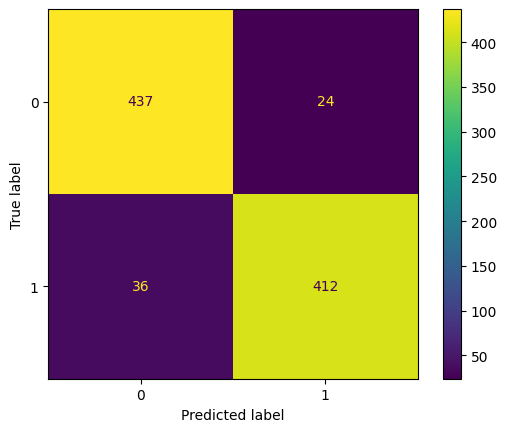

In [27]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [28]:
import joblib
joblib.dump(
    svm,
    "linear_svm_fake_news.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print("Files saved")

Files saved


In [29]:
import os

print(os.listdir())

for file in os.listdir():
    print(file)


['tfidf_vectorizer.pkl', '__notebook__.ipynb', 'linear_svm_fake_news.pkl']
tfidf_vectorizer.pkl
__notebook__.ipynb
linear_svm_fake_news.pkl


In [30]:
import os
print(os.listdir())

['tfidf_vectorizer.pkl', '__notebook__.ipynb', 'linear_svm_fake_news.pkl']


# Combine title and text

In [31]:
import joblib

joblib.dump(X_train, "X_train.pkl")
joblib.dump(X_val, "X_val.pkl")
joblib.dump(X_test, "X_test.pkl")

joblib.dump(y_train, "y_train.pkl")
joblib.dump(y_val, "y_val.pkl")
joblib.dump(y_test, "y_test.pkl")

print("Splits saved")

Splits saved


In [32]:
print(type(X_train))
print(type(X_val))
print(type(X_test))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>


In [33]:
variables = list(globals().keys())

for var in variables:
    
    if (
        "train" in var.lower()
        or "val" in var.lower()
        or "test" in var.lower()
    ):
        
        print(
            var,
            type(globals()[var])
        )

train_test_split <class 'function'>
X_train_text <class 'pandas.core.series.Series'>
y_train <class 'pandas.core.series.Series'>
X_val_text <class 'pandas.core.series.Series'>
X_test_text <class 'pandas.core.series.Series'>
y_val <class 'pandas.core.series.Series'>
y_test <class 'pandas.core.series.Series'>
X_train <class 'scipy.sparse._csr.csr_matrix'>
X_val <class 'scipy.sparse._csr.csr_matrix'>
X_test <class 'scipy.sparse._csr.csr_matrix'>
val_pred <class 'numpy.ndarray'>
test_pred <class 'numpy.ndarray'>


In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_improved = TfidfVectorizer(
    stop_words="english",
    lowercase=True,
    ngram_range=(1, 2),
    max_df=0.85,
    min_df=2,
    sublinear_tf=True,
    max_features=30000
)

X_train_new = tfidf_improved.fit_transform(
    X_train_text
)

X_val_new = tfidf_improved.transform(
    X_val_text
)

X_test_new = tfidf_improved.transform(
    X_test_text
)

print(X_train_new.shape)

(4242, 30000)


In [35]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

C_values = [0.01, 0.1, 1, 5, 10]

best_acc = 0
best_model = None
best_C = None

for c in C_values:

    svm = LinearSVC(
        C=c,
        max_iter=5000
    )

    svm.fit(
        X_train_new,
        y_train
    )

    pred = svm.predict(
        X_val_new
    )

    acc = accuracy_score(
        y_val,
        pred
    )

    print(
        "C =", c,
        "Validation =", acc
    )

    if acc > best_acc:
        best_acc = acc
        best_model = svm
        best_C = c

print("\nBest C:", best_C)
print("Best Validation:", best_acc)

C = 0.01 Validation = 0.8778877887788779
C = 0.1 Validation = 0.9240924092409241
C = 1 Validation = 0.9405940594059405
C = 5 Validation = 0.9416941694169417
C = 10 Validation = 0.9405940594059405

Best C: 5
Best Validation: 0.9416941694169417


In [36]:
from sklearn.metrics import classification_report

final_pred = best_model.predict(
    X_test_new
)

print(
    "Final Test Accuracy:",
    accuracy_score(
        y_test,
        final_pred
    )
)

print(
    classification_report(
        y_test,
        final_pred
    )
)

Final Test Accuracy: 0.944994499449945
              precision    recall  f1-score   support

        FAKE       0.94      0.95      0.95       461
        REAL       0.95      0.94      0.94       448

    accuracy                           0.94       909
   macro avg       0.95      0.94      0.94       909
weighted avg       0.95      0.94      0.94       909



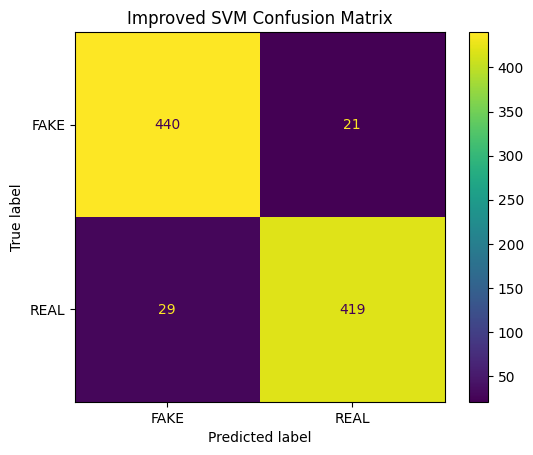

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred
)

plt.title(
    "Improved SVM Confusion Matrix"
)

plt.show()

In [38]:
import joblib

joblib.dump(
    best_model,
    "fake_news_svm.pkl"
)

joblib.dump(
    tfidf_improved,
    "tfidf_vectorizer.pkl"
)

print("Saved successfully")

Saved successfully


# Advanced TF-IDF + SVM tunin

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_v2 = TfidfVectorizer(
    stop_words="english",
    lowercase=True,
    ngram_range=(1,3),      # unigrams + bigrams + trigrams
    min_df=3,
    max_df=0.75,
    max_features=50000,
    sublinear_tf=True
)

X_train_v2 = tfidf_v2.fit_transform(
    X_train_text
)

X_val_v2 = tfidf_v2.transform(
    X_val_text
)

X_test_v2 = tfidf_v2.transform(
    X_test_text
)

print(X_train_v2.shape)

(4242, 50000)


# More focused SVM tuning

In [40]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

C_values = [2, 3, 4, 5, 6, 7, 8]

best_acc = 0
best_model_v2 = None
best_C = None

for c in C_values:

    model = LinearSVC(
        C=c,
        max_iter=10000
    )

    model.fit(
        X_train_v2,
        y_train
    )

    pred = model.predict(
        X_val_v2
    )

    acc = accuracy_score(
        y_val,
        pred
    )

    print(
        "C =", c,
        "Validation =", round(acc, 4)
    )

    if acc > best_acc:
        best_acc = acc
        best_model_v2 = model
        best_C = c

print("\nBest C:", best_C)
print("Best Validation:", best_acc)

C = 2 Validation = 0.945
C = 3 Validation = 0.945
C = 4 Validation = 0.9461
C = 5 Validation = 0.9461
C = 6 Validation = 0.9461
C = 7 Validation = 0.9461
C = 8 Validation = 0.9461

Best C: 4
Best Validation: 0.9460946094609461


In [41]:
from sklearn.metrics import classification_report, accuracy_score

final_pred_v2 = best_model_v2.predict(
    X_test_v2
)

print(
    "Final Test Accuracy:",
    accuracy_score(
        y_test,
        final_pred_v2
    )
)

print(
    classification_report(
        y_test,
        final_pred_v2
    )
)

Final Test Accuracy: 0.944994499449945
              precision    recall  f1-score   support

        FAKE       0.94      0.96      0.95       461
        REAL       0.95      0.93      0.94       448

    accuracy                           0.94       909
   macro avg       0.95      0.94      0.94       909
weighted avg       0.95      0.94      0.94       909



In [42]:
import numpy as np

feature_names = tfidf_improved.get_feature_names_out()

coef = best_model.coef_[0]

top_fake = np.argsort(coef)[:20]
top_real = np.argsort(coef)[-20:]

print("Words indicating FAKE:\n")
print(feature_names[top_fake])

print("\nWords indicating REAL:\n")
print(feature_names[top_real])

Words indicating FAKE:

['october' '2016' 'article' 'election' 'november 2016' 'november' 'source'
 'share' 'print' 'snip' 'advertisement' 'stated' 'hillary' 'mosul' 'email'
 'establishment' 'uk' 'oct' 'corruption' 'photo']

Words indicating REAL:

['president' 'monday' 'sanders' 'republicans' 'march' 'cruz' 'candidates'
 'gop' 'debate' 'republican' 'convention' 'marriage' 'cnn' 'clinton said'
 'presidential' 'sen' 'percent' 'conservative' 'friday' 'said']


In [43]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_test_num = encoder.fit_transform(
    y_test
)

pred_num = encoder.transform(
    final_pred
)

auc = roc_auc_score(
    y_test_num,
    pred_num
)

print("ROC-AUC Score:", round(auc, 4))

ROC-AUC Score: 0.9449


In [44]:
def predict_with_confidence(text):

    vec = tfidf_improved.transform(
        [text]
    )

    score = best_model.decision_function(
        vec
    )[0]

    pred = best_model.predict(
        vec
    )[0]

    confidence = (
        abs(score)
        /
        (abs(score) + 1)
    ) * 100

    print("Prediction:", pred)
    print(
        "Confidence:",
        round(confidence, 2),
        "%"
    )

In [45]:
predict_with_confidence(
"""
Officials announced a new policy to improve transportation and release updates next month.
"""
)

Prediction: REAL
Confidence: 23.35 %


In [46]:
import numpy as np

def predict_with_confidence(text):

    vec = tfidf_improved.transform(
        [text]
    )

    score = best_model.decision_function(
        vec
    )[0]

    confidence = (
        1 /
        (
            1 +
            np.exp(
                -abs(score)
            )
        )
    ) * 100

    prediction = best_model.predict(
        vec
    )[0]

    print("Prediction:", prediction)
    print(
        "Confidence:",
        round(confidence, 2),
        "%"
    )

In [47]:
predict_with_confidence(
"""
Officials announced a new policy to improve transportation and release updates next month.
"""
)

Prediction: REAL
Confidence: 57.56 %


In [48]:
predict_with_confidence(
"""
Breaking secret report proves impossible hidden cure was covered up.
"""
)

Prediction: FAKE
Confidence: 61.23 %


In [49]:
import re

def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"http\S+",
        "",
        text
    )

    text = re.sub(
        r"[^a-zA-Z ]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [50]:
X_train_clean = X_train_text.apply(
    clean_text
)

X_val_clean = X_val_text.apply(
    clean_text
)

X_test_clean = X_test_text.apply(
    clean_text
)

print(
    X_train_clean.iloc[0][:300]
)

charities with ties to hillary clinton will re file at least five tax returns after errors in how donations from foreign governments were disclosed according to a published report reuters reported early thursday that the errors on form s include under reporting or over reporting by millions of dolla


In [51]:
tfidf_clean = TfidfVectorizer(
    stop_words="english",
    lowercase=True,
    ngram_range=(1,2),
    max_df=0.85,
    min_df=2,
    sublinear_tf=True,
    max_features=30000
)

X_train_clean_vec = tfidf_clean.fit_transform(
    X_train_clean
)

X_val_clean_vec = tfidf_clean.transform(
    X_val_clean
)

X_test_clean_vec = tfidf_clean.transform(
    X_test_clean
)

In [52]:
svm_clean = LinearSVC(
    C=5,
    max_iter=5000
)

svm_clean.fit(
    X_train_clean_vec,
    y_train
)

pred = svm_clean.predict(
    X_test_clean_vec
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

Accuracy: 0.9427942794279428


# Tune TF-IDF systematically

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

configs = [

{
"ngram_range":(1,1),
"max_features":20000
},

{
"ngram_range":(1,2),
"max_features":30000
},

{
"ngram_range":(1,2),
"max_features":50000
},

{
"ngram_range":(1,3),
"max_features":30000
}
]

best_score = 0
best_cfg = None

for cfg in configs:

    tfidf = TfidfVectorizer(
        stop_words="english",
        ngram_range=cfg["ngram_range"],
        max_features=cfg["max_features"],
        max_df=0.85,
        min_df=2,
        sublinear_tf=True
    )

    tr = tfidf.fit_transform(X_train_text)

    te = tfidf.transform(X_test_text)

    model = LinearSVC(
        C=5,
        max_iter=5000
    )

    model.fit(
        tr,
        y_train
    )

    pred = model.predict(
        te
    )

    acc = accuracy_score(
        y_test,
        pred
    )

    print(cfg, acc)

    if acc > best_score:
        best_score = acc
        best_cfg = cfg

print("\nBest:", best_cfg)
print("Accuracy:", best_score)

{'ngram_range': (1, 1), 'max_features': 20000} 0.9306930693069307
{'ngram_range': (1, 2), 'max_features': 30000} 0.944994499449945
{'ngram_range': (1, 2), 'max_features': 50000} 0.9427942794279428
{'ngram_range': (1, 3), 'max_features': 30000} 0.9427942794279428

Best: {'ngram_range': (1, 2), 'max_features': 30000}
Accuracy: 0.944994499449945


In [54]:
wrong_idx = []

for i in range(len(y_test)):

    if final_pred[i] != y_test.iloc[i]:

        wrong_idx.append(i)

print(
    "Wrong predictions:",
    len(wrong_idx)
)

Wrong predictions: 50


In [55]:
i = wrong_idx[0]

print("TEXT:\n")
print(X_test_text.iloc[i][:1500])

print("\nACTUAL:")
print(y_test.iloc[i])

print("\nPREDICTED:")
print(final_pred[i])

TEXT:

As they went on their rampage, the men who killed 12 people in Paris this week yelled that they had “avenged the prophet.” They followed in the path of other terrorists who have bombed newspaper offices, stabbed a filmmaker and killed writers and translators, all to mete out what they believe is the proper Koranic punishment for blasphemy. But in fact, the Koran prescribes no punishment for blasphemy. Like so many of the most fanatical and violent aspects of Islamic terrorism today, the idea that Islam requires that insults against the prophet Muhammad be met with violence is a creation of politicians and clerics to serve a political agenda.

One holy book is deeply concerned with blasphemy: the Bible. In the Old Testament, blasphemy and blasphemers are condemned and prescribed harsh punishment. The best-known passage on this is Leviticus 24:16 : “Anyone who blasphemes the name of the Lord is to be put to death. The entire assembly must stone them. Whether foreigner or native-bo

# Title + Text together

In [56]:
print(type(df))
print(df.columns)
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')
(6060, 4)


In [57]:
from sklearn.model_selection import train_test_split


df["combined"] = (
    df["title"].fillna("")
    + " "
    + df["text"].fillna("")
)

X = df["combined"]
y = df["label"]


X_train_combined, X_temp, y_train_combined, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


X_val_combined, X_test_combined, y_val_combined, y_test_combined = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(len(X_train_combined))
print(len(X_val_combined))
print(len(X_test_combined))

4242
909
909


In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_title = TfidfVectorizer(
    stop_words="english",
    lowercase=True,
    ngram_range=(1,2),
    max_df=0.85,
    min_df=2,
    sublinear_tf=True,
    max_features=30000
)

X_train_title = tfidf_title.fit_transform(
    X_train_combined
)

X_val_title = tfidf_title.transform(
    X_val_combined
)

X_test_title = tfidf_title.transform(
    X_test_combined
)

print(X_train_title.shape)

(4242, 30000)


In [59]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

svm_title = LinearSVC(
    C=5,
    max_iter=5000
)

svm_title.fit(
    X_train_title,
    y_train_combined
)

pred = svm_title.predict(
    X_test_title
)

print(
    "Title + Text Accuracy:",
    accuracy_score(
        y_test_combined,
        pred
    )
)

Title + Text Accuracy: 0.9427942794279428


In [60]:
import joblib


joblib.dump(
    best_model,
    "final_fake_news_svm.pkl"
)


joblib.dump(
    tfidf_improved,
    "final_tfidf_vectorizer.pkl"
)

print("Files saved successfully")

Files saved successfully


In [61]:
import os

print(os.listdir())

['y_val.pkl', 'X_test.pkl', 'y_train.pkl', 'final_fake_news_svm.pkl', 'tfidf_vectorizer.pkl', '__notebook__.ipynb', 'linear_svm_fake_news.pkl', 'X_val.pkl', 'final_tfidf_vectorizer.pkl', 'y_test.pkl', 'X_train.pkl', 'fake_news_svm.pkl']


In [62]:
import joblib

loaded_model = joblib.load(
    "final_fake_news_svm.pkl"
)

loaded_vectorizer = joblib.load(
    "final_tfidf_vectorizer.pkl"
)

print("Loaded successfully")

Loaded successfully


In [63]:
sample = """
Government announces new economic reforms.
"""

vec = loaded_vectorizer.transform(
    [sample]
)

print(
    loaded_model.predict(
        vec
    )[0]
)

REAL


In [64]:
import os

print(
    os.listdir(
        "/kaggle/working"
    )
)

['y_val.pkl', 'X_test.pkl', 'y_train.pkl', 'final_fake_news_svm.pkl', 'tfidf_vectorizer.pkl', '__notebook__.ipynb', 'linear_svm_fake_news.pkl', 'X_val.pkl', 'final_tfidf_vectorizer.pkl', 'y_test.pkl', 'X_train.pkl', 'fake_news_svm.pkl']


In [65]:
import os

files = [
    "final_fake_news_svm.pkl",
    "final_tfidf_vectorizer.pkl",
    "fake_news_svm.pkl",
    "tfidf_vectorizer.pkl",
    "linear_svm_fake_news.pkl"
]

for f in files:
    print(
        f,
        os.path.getsize(
            "/kaggle/working/" + f
        ) / 1024,
        "KB"
    )

final_fake_news_svm.pkl 235.2294921875 KB
final_tfidf_vectorizer.pkl 1168.3525390625 KB
fake_news_svm.pkl 235.2294921875 KB
tfidf_vectorizer.pkl 1168.3525390625 KB
linear_svm_fake_news.pkl 458.3388671875 KB


In [66]:
def predict_news(text):

    vec = tfidf_improved.transform(
        [text]
    )

    pred = best_model.predict(
        vec
    )[0]

    return pred

In [67]:
predict_news(
    "Government announces economic reforms"
)

'REAL'

In [68]:
predict_news(
"Scientists discover new water source on Mars according to official report"
)

'FAKE'

In [69]:
predict_news(
"Shocking secret government plan exposed overnight"
)

'REAL'

In [70]:
predict_news(
"Breaking: celebrity reveals impossible cure doctors hide"
)

'FAKE'

In [71]:
sample = """
Officials announced a new economic policy aimed at increasing employment and reducing inflation. The reforms will begin next quarter and updates will be published regularly.
"""

predict_news(sample)

'FAKE'

# predict function

In [72]:
def predict_news(text):

    transformed_text = tfidf.transform(
        [text]
    )

    prediction = svm.predict(
        transformed_text
    )[0]

    print("\nArticle:")
    print(text[:300])

    print("\nPrediction:", prediction)

    return prediction

In [73]:
text = """
The local government announced a plan to improve public transportation by adding electric buses and expanding routes over the next year. Officials stated that the program will begin with pilot testing and progress updates will be released regularly. Transportation analysts said similar projects have improved commuting efficiency in other regions.
"""

predict_news(text)


Article:

The local government announced a plan to improve public transportation by adding electric buses and expanding routes over the next year. Officials stated that the program will begin with pilot testing and progress updates will be released regularly. Transportation analysts said similar projects hav

Prediction: FAKE


'FAKE'

In [74]:
text = """
Anonymous sources claimed that researchers secretly developed a technology capable of controlling weather patterns worldwide. The report provided no published evidence and suggested that official agencies are hiding the information from the public.
"""

predict_news(text)


Article:

Anonymous sources claimed that researchers secretly developed a technology capable of controlling weather patterns worldwide. The report provided no published evidence and suggested that official agencies are hiding the information from the public.


Prediction: FAKE


'FAKE'

In [75]:
text = """
A technology company introduced a new artificial intelligence system intended to summarize documents faster than previous tools. Company representatives stated that additional testing is required before wider deployment.
"""

predict_news(text)


Article:

A technology company introduced a new artificial intelligence system intended to summarize documents faster than previous tools. Company representatives stated that additional testing is required before wider deployment.


Prediction: FAKE


'FAKE'

# Experiment 6: Hyperparameter Optimization using GridSearchCV

In this experiment, GridSearchCV is used to identify the optimal regularization parameter (C) for the Linear Support Vector Machine classifier. A 5-fold cross-validation strategy is employed to evaluate different values of C and select the model with the highest mean cross-validation accuracy.

In [76]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

In [77]:
param_grid = {
    "C": [0.01, 0.1, 0.5, 1, 2, 5, 10, 15, 20]
}

In [78]:
grid_search = GridSearchCV(
    estimator=LinearSVC(
        random_state=42,
        max_iter=5000
    ),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

In [79]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(cv=5, estimator=LinearSVC(max_iter=5000, random_state=42),
             n_jobs=-1, param_grid={'C': [0.01, 0.1, 0.5, 1, 2, 5, 10, 15, 20]},
             return_train_score=True, scoring='accuracy', verbose=2)

In [80]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'C': 2}

Best Cross Validation Accuracy:
0.9297480943173989


In [81]:
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)

results = results[
    [
        "param_C",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
]

results.sort_values(
    by="rank_test_score",
    inplace=True
)

results

,param_C,mean_test_score,std_test_score,rank_test_score
4,2.00,0.929748,0.006798,1
5,5.00,0.928805,0.007574,2
3,1.00,0.927862,0.007230,3
7,15.00,0.927626,0.007537,4
6,10.00,0.927626,0.007686,5
8,20.00,0.927390,0.007501,6
2,0.50,0.924089,0.007696,7
1,0.10,0.907115,0.009181,8
0,0.01,0.858551,0.012182,9


In [82]:
best_svm = grid_search.best_estimator_

In [83]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred = best_svm.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print()

print(classification_report(y_test, y_pred))
print()

print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.933993399339934

              precision    recall  f1-score   support

        FAKE       0.93      0.95      0.94       461
        REAL       0.94      0.92      0.93       448

    accuracy                           0.93       909
   macro avg       0.93      0.93      0.93       909
weighted avg       0.93      0.93      0.93       909


[[436  25]
 [ 35 413]]


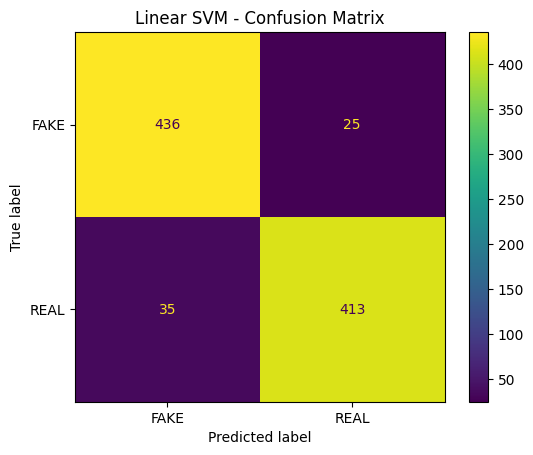

In [84]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(best_svm, X_test, y_test)

plt.title("Linear SVM - Confusion Matrix")
plt.show()

In [85]:
best_C = grid_search.best_params_["C"]
best_cv_accuracy = grid_search.best_score_
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Best C: {best_C}")
print(f"Best CV Accuracy: {best_cv_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Best C: 2
Best CV Accuracy: 0.9297
Test Accuracy: 0.9340


# Experiment 8: Feature Importance Analysis

The Linear Support Vector Machine is a linear classifier whose learned coefficients indicate the contribution of each TF-IDF feature to the classification decision. Features with large positive coefficients strongly support one class, while features with large negative coefficients support the other class. This analysis helps interpret the model by identifying the most influential words for fake and real news classification.

In [86]:
from sklearn.svm import LinearSVC

best_svm = LinearSVC(
    C=2,
    max_iter=5000,
    random_state=42
)

best_svm.fit(X_train_new, y_train)

LinearSVC(C=2, max_iter=5000, random_state=42)

In [87]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = best_svm.predict(X_test_new)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9438943894389439
              precision    recall  f1-score   support

        FAKE       0.94      0.95      0.95       461
        REAL       0.95      0.93      0.94       448

    accuracy                           0.94       909
   macro avg       0.94      0.94      0.94       909
weighted avg       0.94      0.94      0.94       909

[[440  21]
 [ 30 418]]


## Experiment: ROC Curve and ROC-AUC Analysis

Since the Linear Support Vector Machine (`LinearSVC`) does not provide probability estimates through `predict_proba()`, the decision function scores are used to evaluate the classifier using the Receiver Operating Characteristic (ROC) curve and the Area Under the Curve (AUC). The ROC-AUC metric measures the classifier's ability to distinguish between fake and real news across different decision thresholds.

In [88]:
from sklearn.metrics import roc_curve, roc_auc_score

decision_scores = best_svm.decision_function(X_test_new)

In [89]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

le.fit(best_svm.classes_)

print(le.classes_)

['FAKE' 'REAL']


In [90]:
y_test_encoded = le.transform(y_test)
print(y_test_encoded[:10])

[1 1 0 0 1 1 1 1 0 0]


In [91]:
roc_auc = roc_auc_score(
    y_test_encoded,
    decision_scores
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9883889835760769


In [92]:
fpr, tpr, thresholds = roc_curve(
    y_test_encoded,
    decision_scores
)

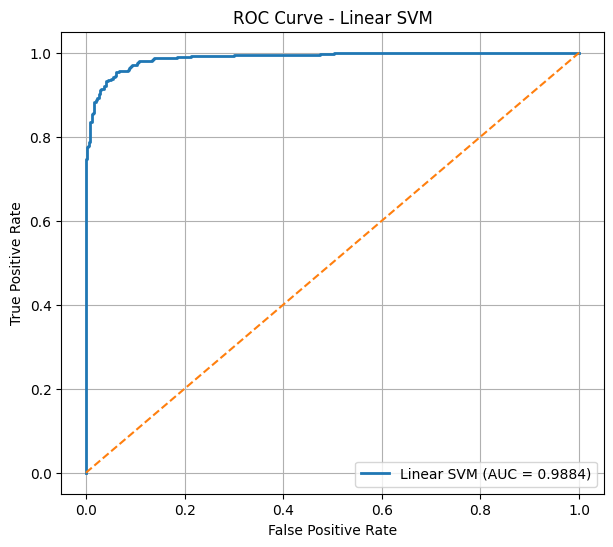

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Linear SVM (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Linear SVM")

plt.legend()

plt.grid(True)

plt.show()

# Experiment 9: Feature Importance Analysis for Linear SVM

The Linear Support Vector Machine is a linear classifier that assigns a coefficient to every TF-IDF feature. Features with large positive coefficients contribute more strongly toward one class, while features with large negative coefficients contribute toward the other class. Examining these coefficients helps interpret the model by identifying the most influential words for fake and real news classification.

In [94]:
print(best_svm.n_features_in_)
print(len(tfidf.get_feature_names_out()))

30000
30000


In [95]:
import pandas as pd

feature_names = tfidf.get_feature_names_out()
coefficients = best_svm.coef_[0]

importance_df = pd.DataFrame({
    "Word": feature_names,
    "Coefficient": coefficients
})

importance_df.head()

,Word,Coefficient
0,00,-0.320580
1,000,-0.068142
2,000 000,-0.193472
3,000 according,0.029143
4,000 american,0.025104


In [96]:
top_real = importance_df.sort_values(
    by="Coefficient",
    ascending=False
).head(20)

top_real

,Word,Coefficient
22956,safety net,2.450106
5940,conservative media,1.547363
10776,french government,1.536834
19244,people stop,1.447524
23832,seminar,1.391677
20373,president ronald reagan,1.326169
5153,clinton really,1.272058
22020,republican base,1.270010
5281,club,1.249990
11355,goodwill,1.246457


In [97]:
top_fake = importance_df.sort_values(
    by="Coefficient",
    ascending=True
).head(20)

top_fake

,Word,Coefficient
407,2016 leave comment,-2.761140
18138,obstruct,-2.757657
2160,arnaldo rodgers,-2.236428
8778,election election,-1.984157
17838,north atlantic,-1.749814
17827,normalize relations,-1.742653
24117,sexual,-1.629344
24726,son,-1.613422
20543,primary said,-1.520708
25264,state presidential,-1.503216


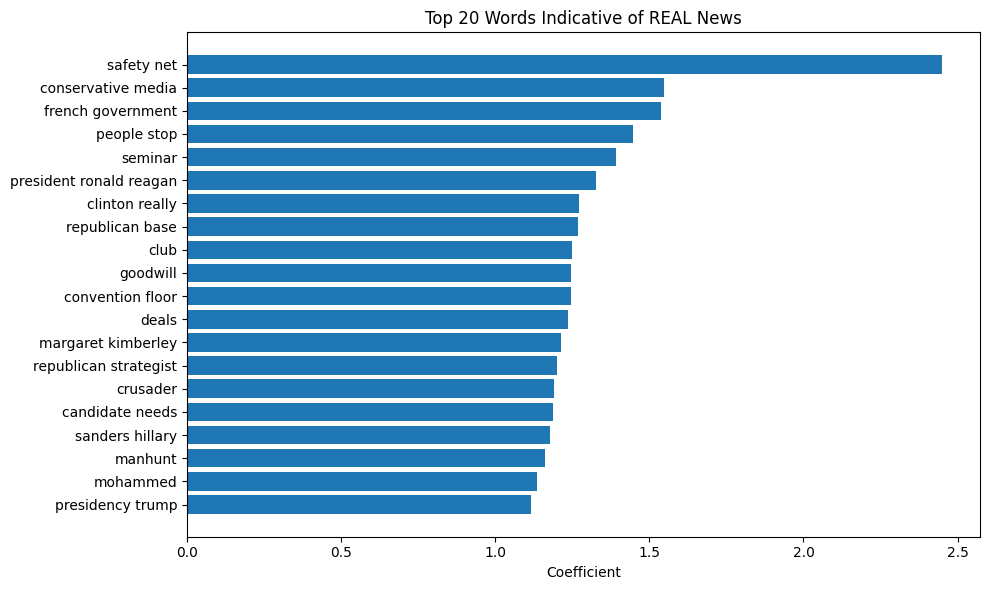

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top_real["Word"],
    top_real["Coefficient"]
)

plt.title("Top 20 Words Indicative of REAL News")

plt.xlabel("Coefficient")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

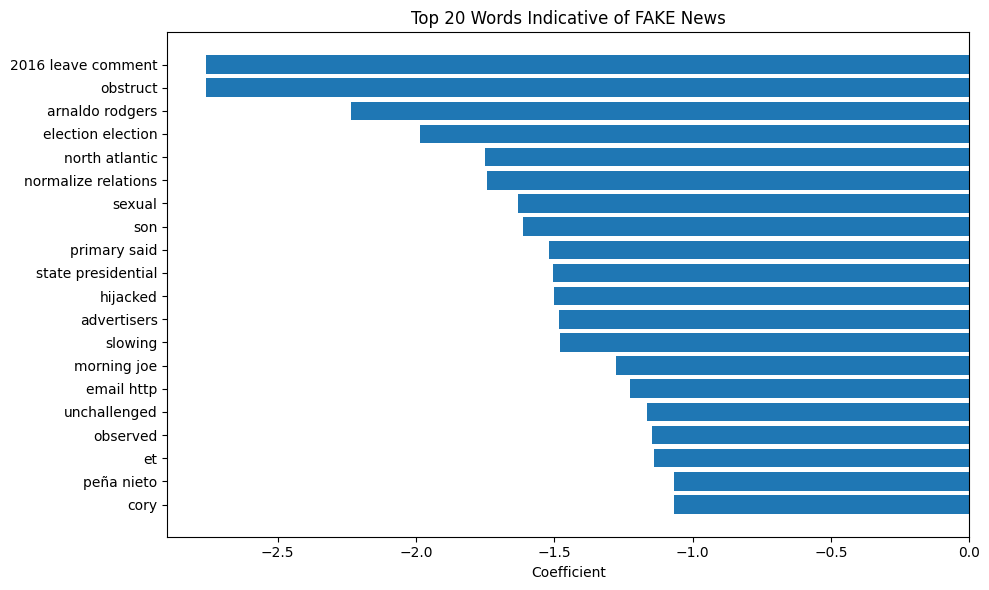

In [99]:
plt.figure(figsize=(10,6))

plt.barh(
    top_fake["Word"],
    top_fake["Coefficient"]
)

plt.title("Top 20 Words Indicative of FAKE News")

plt.xlabel("Coefficient")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()